# parameter recovery


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["OMP_NUM_THREADS"] = "1"
import seaborn as sns
from scipy.io import loadmat, savemat
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import ast
import warnings
from matplotlib.ticker import FormatStrFormatter
import statsmodels.api as sm

In [2]:
outputFolderName = r"param_recovery_4_visualization_v1"
inputFolderName = r"param_recovery_3_param_recovery_v1"

if not os.path.exists(outputFolderName):
    os.makedirs(outputFolderName)


In [3]:
file_path = os.path.join(inputFolderName, "alpha_comparison.csv")
df = pd.read_csv(file_path)

fit_alpha_plus = df["fit_alpha_plus"]
fit_alpha_minus = df["fit_alpha_minus"]
sim_alpha_plus = df["sim_alpha_plus"]
sim_alpha_minus = df["sim_alpha_minus"]

In [4]:
def plot_with_regression(ax, x, y, title):
    x = np.array(x)
    y = np.array(y)

    # Remove NaNs only
    mask_valid = ~np.isnan(x) & ~np.isnan(y)
    x = x[mask_valid]
    y = y[mask_valid]

    # Scatter plot
    ax.scatter(x, y, alpha=0.5, edgecolor='none', s=30)

    # Linear regression
    x_vals = x.reshape(-1, 1)
    model = LinearRegression().fit(x_vals, y)
    y_pred = model.predict(x_vals)

    # Identity line
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())
    ax.plot(
        [min_val - 0.1, max_val + 0.1],
        [min_val - 0.1, max_val + 0.1],
        '--',
        color='black',
        linewidth=0.5
    )
    # R²
    r2 = r2_score(y, y_pred)
    ax.set_title(f"{title}\n$R^2$ = {r2:.2f}")
    ax.set_xlabel("Fitted")
    ax.set_ylabel("Simulated")
    ax.set_xlim(min_val - 0.01, max_val + 0.01)
    ax.set_ylim(min_val - 0.01, max_val + 0.01)

    # make axis square
    ax.set_box_aspect(1)

    # remove top and right borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # tick labels with 1 decimal place
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

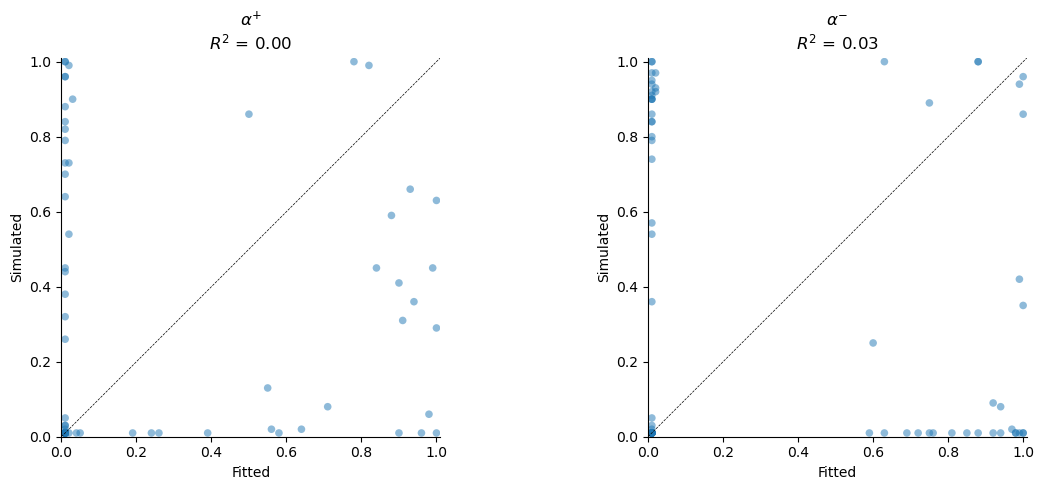

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


plot_with_regression(
    axes[0],
    fit_alpha_plus,
    sim_alpha_plus,
    r"$\alpha^{+}$"
)

plot_with_regression(
    axes[1],
    fit_alpha_minus,
    sim_alpha_minus,
    r"$\alpha^{-}$"
)

plt.tight_layout()

# save
save_path = os.path.join(outputFolderName, "alpha_plus_minus_scatter.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

# debug